# Instagram Photo Framer

This notebook processes photos from the source folder and produces:

- Non-framed processed outputs in `instagram-processed/`
- Framed outputs in `instagram-framed/`

It supports:

- Splitting horizontal photos into exact left and right halves
- Keeping seam continuity for carousel pairs
- Producing framed outputs that are exactly 1080x1440 with variable frame thickness

The source folder remains unchanged.

## 1) Set Up Environment and Dependencies

Install packages if needed, then import dependencies and print versions for reproducibility.

In [16]:
# If PIL is missing, uncomment and run the next line:
# %pip install pillow

import os
import sys
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

from IPython.display import HTML, clear_output, display
from PIL import Image, ImageOps

print(f"Python: {sys.version.split()[0]}")
print(f"Pillow: {Image.__version__}")

Python: 3.14.3
Pillow: 12.2.0


## 2) Create Project Configuration

Define all runtime settings in one place. Adjust values here before running the full pipeline.

In [17]:
@dataclass(frozen=True)
class AppConfig:
    source_dir: Path
    processed_dir: Path
    framed_dir: Path
    target_size: Tuple[int, int]
    baseline_frame_width: int
    frame_color: Tuple[int, int, int]
    allow_upscale: bool
    image_extensions: Tuple[str, ...]
    jpeg_quality: int
    jpeg_subsampling: int
    copy_portraits_without_reencode: bool
    show_progress: bool


PROJECT_ROOT = Path.cwd()
CONFIG = AppConfig(
    source_dir=PROJECT_ROOT / "instagram",
    processed_dir=PROJECT_ROOT / "instagram-processed",
    framed_dir=PROJECT_ROOT / "instagram-framed",
    target_size=(1080, 1440),
    baseline_frame_width=60,
    frame_color=(255, 255, 255),
    allow_upscale=True,
    image_extensions=(".jpg", ".jpeg", ".JPG", ".JPEG"),
    jpeg_quality=100,
    jpeg_subsampling=0,
    copy_portraits_without_reencode=True,
    show_progress=True,
)

print("Project root:", PROJECT_ROOT)
print("Source dir:", CONFIG.source_dir)
print("Processed dir:", CONFIG.processed_dir)
print("Framed dir:", CONFIG.framed_dir)
print("Target framed size:", CONFIG.target_size)
print("Baseline frame width:", CONFIG.baseline_frame_width)
print("JPEG quality settings:", CONFIG.jpeg_quality, "subsampling", CONFIG.jpeg_subsampling)

Project root: /Users/silasfaldenew/GitHub/photo-framer
Source dir: /Users/silasfaldenew/GitHub/photo-framer/instagram
Processed dir: /Users/silasfaldenew/GitHub/photo-framer/instagram-processed
Framed dir: /Users/silasfaldenew/GitHub/photo-framer/instagram-framed
Target framed size: (1080, 1440)
Baseline frame width: 60
JPEG quality settings: 100 subsampling 0


## 3) Implement Core Data Structures

Use typed dataclasses to capture actions, stats, and framing details for traceable processing.

In [18]:
@dataclass
class BorderSpec:
    left: int
    top: int
    right: int
    bottom: int


@dataclass
class ProcessRecord:
    source_name: str
    mode: str
    processed_outputs: List[str]
    framed_outputs: List[str]


@dataclass
class RunStats:
    portraits: int = 0
    landscapes: int = 0
    processed_written: int = 0
    framed_written: int = 0
    errors: int = 0


print("Data structures ready.")

Data structures ready.


## 4) Implement Core Logic Functions

These functions handle discovery, exact horizontal splitting, side-aware framing, fixed-size final framing, and output writing.

In [19]:
def ensure_output_dirs(cfg: AppConfig) -> None:
    cfg.processed_dir.mkdir(parents=True, exist_ok=True)
    cfg.framed_dir.mkdir(parents=True, exist_ok=True)


def list_source_images(cfg: AppConfig) -> List[Path]:
    if not cfg.source_dir.exists():
        raise FileNotFoundError(f"Source directory does not exist: {cfg.source_dir}")
    files = [
        p for p in sorted(cfg.source_dir.iterdir())
        if p.is_file() and p.suffix in cfg.image_extensions
    ]
    return files


def load_image(path: Path) -> Image.Image:
    """Load image and normalize EXIF orientation."""
    with Image.open(path) as img:
        return ImageOps.exif_transpose(img).convert("RGB")


def load_image_and_metadata(path: Path) -> Tuple[Image.Image, Optional[bytes], Optional[bytes]]:
    with Image.open(path) as img:
        normalized = ImageOps.exif_transpose(img).convert("RGB")
        exif_bytes = img.info.get("exif")
        icc_profile = img.info.get("icc_profile")
    return normalized, exif_bytes, icc_profile


def is_landscape(img: Image.Image) -> bool:
    return img.width > img.height


def split_landscape_exact(img: Image.Image) -> Tuple[Image.Image, Image.Image]:
    """Split exactly at midpoint, no overlap and no gap."""
    w, h = img.size
    mid = w // 2
    left = img.crop((0, 0, mid, h))
    right = img.crop((mid, 0, w, h))
    return left, right


def fit_inside(
    width: int,
    height: int,
    max_width: int,
    max_height: int,
    allow_upscale: bool,
) -> Tuple[int, int]:
    if width <= 0 or height <= 0:
        raise ValueError("Image dimensions must be positive")
    if max_width <= 0 or max_height <= 0:
        raise ValueError("Bounding dimensions must be positive")

    scale = min(max_width / width, max_height / height)
    if not allow_upscale:
        scale = min(scale, 1.0)

    new_w = max(1, int(round(width * scale)))
    new_h = max(1, int(round(height * scale)))
    return new_w, new_h


def render_framed_full(
    img: Image.Image,
    target_size: Tuple[int, int],
    baseline: int,
    frame_color: Tuple[int, int, int],
    allow_upscale: bool,
) -> Tuple[Image.Image, BorderSpec]:
    """Create 1080x1440 framed output with baseline frame and variable extra margin."""
    target_w, target_h = target_size
    avail_w = target_w - (2 * baseline)
    avail_h = target_h - (2 * baseline)
    if avail_w <= 0 or avail_h <= 0:
        raise ValueError("Baseline frame width is too large for target size")

    out = Image.new("RGB", (target_w, target_h), frame_color)
    new_w, new_h = fit_inside(img.width, img.height, avail_w, avail_h, allow_upscale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    x = baseline + ((avail_w - new_w) // 2)
    y = baseline + ((avail_h - new_h) // 2)
    out.paste(resized, (x, y))

    border = BorderSpec(
        left=x,
        top=y,
        right=target_w - (x + new_w),
        bottom=target_h - (y + new_h),
    )
    return out, border


def render_framed_split_half(
    img: Image.Image,
    side: str,
    target_size: Tuple[int, int],
    baseline: int,
    frame_color: Tuple[int, int, int],
    allow_upscale: bool,
) -> Tuple[Image.Image, BorderSpec]:
    """
    side='left': no right border, baseline on left/top/bottom.
    side='right': no left border, baseline on right/top/bottom.
    """
    if side not in {"left", "right"}:
        raise ValueError("side must be 'left' or 'right'")

    target_w, target_h = target_size
    avail_w = target_w - baseline
    avail_h = target_h - (2 * baseline)
    if avail_w <= 0 or avail_h <= 0:
        raise ValueError("Baseline frame width is too large for target size")

    new_w, new_h = fit_inside(img.width, img.height, avail_w, avail_h, allow_upscale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    out = Image.new("RGB", (target_w, target_h), frame_color)
    y = baseline + ((avail_h - new_h) // 2)

    if side == "left":
        # Seam is right edge; keep it flush.
        x = target_w - new_w
        out.paste(resized, (x, y))
        border = BorderSpec(
            left=x,
            top=y,
            right=0,
            bottom=target_h - (y + new_h),
        )
    else:
        # Seam is left edge; keep it flush.
        x = 0
        out.paste(resized, (x, y))
        border = BorderSpec(
            left=0,
            top=y,
            right=target_w - new_w,
            bottom=target_h - (y + new_h),
        )

    return out, border


def save_jpeg(
    img: Image.Image,
    path: Path,
    cfg: AppConfig,
    exif_bytes: Optional[bytes] = None,
    icc_profile: Optional[bytes] = None,
) -> None:
    """Save with maximum JPEG fidelity settings to avoid quality loss from encoder settings."""
    path.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {
        "format": "JPEG",
        "quality": cfg.jpeg_quality,
        "subsampling": cfg.jpeg_subsampling,
        "optimize": False,
        "progressive": False,
    }
    if exif_bytes is not None:
        kwargs["exif"] = exif_bytes
    if icc_profile is not None:
        kwargs["icc_profile"] = icc_profile
    img.save(path, **kwargs)


def show_progress_visual(done: int, total: int, current_name: str) -> None:
    pct = 100.0 if total == 0 else (done / total) * 100
    bar = (
        f"<div style='width:100%;border:1px solid #bbb;border-radius:6px;height:20px;'>"
        f"<div style='width:{pct:.1f}%;height:100%;background:#3a7;'>"
        f"</div></div>"
    )
    clear_output(wait=True)
    display(HTML(bar))
    print(f"Progress: {done}/{total} ({pct:.1f}%)")
    print(f"Current: {current_name}")


def process_all(cfg: AppConfig) -> Tuple[List[ProcessRecord], RunStats, Dict[str, BorderSpec]]:
    ensure_output_dirs(cfg)
    files = list_source_images(cfg)

    records: List[ProcessRecord] = []
    stats = RunStats()
    framed_borders: Dict[str, BorderSpec] = {}

    total = len(files)
    for idx, src in enumerate(files, start=1):
        try:
            img, exif_bytes, icc_profile = load_image_and_metadata(src)
            stem = src.stem
            suffix = ".jpg"

            if is_landscape(img):
                stats.landscapes += 1
                left_img, right_img = split_landscape_exact(img)

                proc_left = cfg.processed_dir / f"{stem}_L{suffix}"
                proc_right = cfg.processed_dir / f"{stem}_R{suffix}"
                save_jpeg(left_img, proc_left, cfg, exif_bytes=exif_bytes, icc_profile=icc_profile)
                save_jpeg(right_img, proc_right, cfg, exif_bytes=exif_bytes, icc_profile=icc_profile)
                stats.processed_written += 2

                framed_left, border_left = render_framed_split_half(
                    left_img,
                    side="left",
                    target_size=cfg.target_size,
                    baseline=cfg.baseline_frame_width,
                    frame_color=cfg.frame_color,
                    allow_upscale=cfg.allow_upscale,
                )
                framed_right, border_right = render_framed_split_half(
                    right_img,
                    side="right",
                    target_size=cfg.target_size,
                    baseline=cfg.baseline_frame_width,
                    frame_color=cfg.frame_color,
                    allow_upscale=cfg.allow_upscale,
                )

                fr_left = cfg.framed_dir / f"{stem}_L{suffix}"
                fr_right = cfg.framed_dir / f"{stem}_R{suffix}"
                save_jpeg(framed_left, fr_left, cfg, exif_bytes=exif_bytes, icc_profile=icc_profile)
                save_jpeg(framed_right, fr_right, cfg, exif_bytes=exif_bytes, icc_profile=icc_profile)
                stats.framed_written += 2

                framed_borders[fr_left.name] = border_left
                framed_borders[fr_right.name] = border_right

                records.append(
                    ProcessRecord(
                        source_name=src.name,
                        mode="landscape_split",
                        processed_outputs=[proc_left.name, proc_right.name],
                        framed_outputs=[fr_left.name, fr_right.name],
                    )
                )
            else:
                stats.portraits += 1

                proc_out = cfg.processed_dir / f"{stem}{suffix}"
                if cfg.copy_portraits_without_reencode:
                    shutil.copy2(src, proc_out)
                else:
                    save_jpeg(img, proc_out, cfg, exif_bytes=exif_bytes, icc_profile=icc_profile)
                stats.processed_written += 1

                framed_img, border = render_framed_full(
                    img,
                    target_size=cfg.target_size,
                    baseline=cfg.baseline_frame_width,
                    frame_color=cfg.frame_color,
                    allow_upscale=cfg.allow_upscale,
                )
                fr_out = cfg.framed_dir / f"{stem}{suffix}"
                save_jpeg(framed_img, fr_out, cfg, exif_bytes=exif_bytes, icc_profile=icc_profile)
                stats.framed_written += 1

                framed_borders[fr_out.name] = border

                records.append(
                    ProcessRecord(
                        source_name=src.name,
                        mode="portrait_or_square",
                        processed_outputs=[proc_out.name],
                        framed_outputs=[fr_out.name],
                    )
                )

            if cfg.show_progress:
                show_progress_visual(idx, total, src.name)
            else:
                print(f"OK: {src.name}")
        except Exception as exc:
            stats.errors += 1
            print(f"ERROR: {src.name}: {exc}")

    if cfg.show_progress:
        show_progress_visual(total, total, "Complete")

    return records, stats, framed_borders

## 5) Run a Minimal End-to-End Flow

Run processing for the full source directory and collect records and border diagnostics.

In [20]:
source_files = list_source_images(CONFIG)
print(f"Discovered source files: {len(source_files)}")

landscape_count = 0
portrait_count = 0
for p in source_files:
    img = load_image(p)
    if is_landscape(img):
        landscape_count += 1
    else:
        portrait_count += 1

print(f"Portrait/square inputs: {portrait_count}")
print(f"Landscape inputs: {landscape_count}")
print("Ready to run full processing in Section 7 after function patching.")

Discovered source files: 44
Portrait/square inputs: 39
Landscape inputs: 5
Ready to run full processing in Section 7 after function patching.


## 6) Add Basic Unit Tests

These lightweight tests validate core split and framing behavior, including one failure-path test.

In [21]:
def run_basic_tests() -> None:
    # Happy path: split preserves total width and exact seam.
    test_img = Image.new("RGB", (2161, 1440), (10, 20, 30))
    left, right = split_landscape_exact(test_img)
    assert left.width + right.width == test_img.width
    assert left.height == test_img.height
    assert right.height == test_img.height

    # Happy path: full framed output is exact 1080x1440 and respects baseline frame.
    framed, border = render_framed_full(
        Image.new("RGB", (3000, 4500), (50, 60, 70)),
        target_size=(1080, 1440),
        baseline=60,
        frame_color=(255, 255, 255),
        allow_upscale=True,
    )
    assert framed.size == (1080, 1440)
    assert border.left >= 60
    assert border.right >= 60
    assert border.top >= 60
    assert border.bottom >= 60

    # Happy path: split sides respect seam-side zero and outer-side baseline.
    left_framed, left_border = render_framed_split_half(
        Image.new("RGB", (1080, 1440), (1, 1, 1)),
        side="left",
        target_size=(1080, 1440),
        baseline=40,
        frame_color=(255, 255, 255),
        allow_upscale=True,
    )
    right_framed, right_border = render_framed_split_half(
        Image.new("RGB", (1080, 1440), (1, 1, 1)),
        side="right",
        target_size=(1080, 1440),
        baseline=40,
        frame_color=(255, 255, 255),
        allow_upscale=True,
    )
    assert left_framed.size == (1080, 1440)
    assert right_framed.size == (1080, 1440)
    assert left_border.right == 0
    assert left_border.left >= 40
    assert right_border.left == 0
    assert right_border.right >= 40

    # Failure case: invalid side argument should raise.
    try:
        render_framed_split_half(
            Image.new("RGB", (1080, 1440), (1, 1, 1)),
            side="bad",
            target_size=(1080, 1440),
            baseline=40,
            frame_color=(255, 255, 255),
            allow_upscale=True,
        )
        raise AssertionError("Expected ValueError for invalid side")
    except ValueError:
        pass

    print("All basic tests passed.")


run_basic_tests()

All basic tests passed.


## 7) Inspect Output and Debug in VS Code

Print validation checks and quick diagnostics for output structure and final dimensions.

In [22]:
def bytes_to_kb(path: Path) -> float:
    return path.stat().st_size / 1024.0


def make_contact_sheet(paths: List[Path], columns: int = 3, thumb_size: Tuple[int, int] = (270, 360)) -> Image.Image:
    if not paths:
        return Image.new("RGB", (thumb_size[0], thumb_size[1]), (255, 255, 255))

    rows = (len(paths) + columns - 1) // columns
    sheet = Image.new("RGB", (columns * thumb_size[0], rows * thumb_size[1]), (245, 245, 245))

    for i, path in enumerate(paths):
        with Image.open(path) as img:
            tile = ImageOps.fit(img.convert("RGB"), thumb_size, method=Image.Resampling.LANCZOS)
        x = (i % columns) * thumb_size[0]
        y = (i // columns) * thumb_size[1]
        sheet.paste(tile, (x, y))

    return sheet


def show_example_outputs(cfg: AppConfig, records: List[ProcessRecord], max_examples: int = 6) -> None:
    if not records:
        print("No records to preview.")
        return

    source_paths: List[Path] = []
    framed_paths: List[Path] = []

    for rec in records:
        if len(source_paths) >= max_examples:
            break
        source_paths.append(cfg.source_dir / rec.source_name)
        framed_paths.append(cfg.framed_dir / rec.framed_outputs[0])

    src_sheet = make_contact_sheet(source_paths, columns=3)
    framed_sheet = make_contact_sheet(framed_paths, columns=3)

    print("Example source images")
    display(src_sheet)
    print("Example framed outputs (1080x1440)")
    display(framed_sheet)

Progress: 44/44 (100.0%)
Current: Complete
Validation checks passed.
Final run summary:
Portrait/square inputs: 39
Landscape inputs: 5
Processed files written: 49
Framed files written: 49
Errors: 0

File size diagnostics (KB)
source -> processed -> framed
DSC_3156.jpg: 1925.8 -> 1112.3 -> 1809.9
DSC_3157.jpg: 2016.9 -> 2016.9 -> 1875.4
DSC_3158.jpg: 2106.8 -> 2106.8 -> 1993.4
DSC_3159.jpg: 1686.3 -> 1686.3 -> 1632.2
DSC_3161.jpg: 1909.5 -> 1909.5 -> 1823.3
DSC_3162.jpg: 1755.2 -> 1755.2 -> 1626.3
DSC_3162_01.jpg: 1504.0 -> 1504.0 -> 1507.4
DSC_3163.jpg: 1618.5 -> 1618.5 -> 1638.8
Example source images


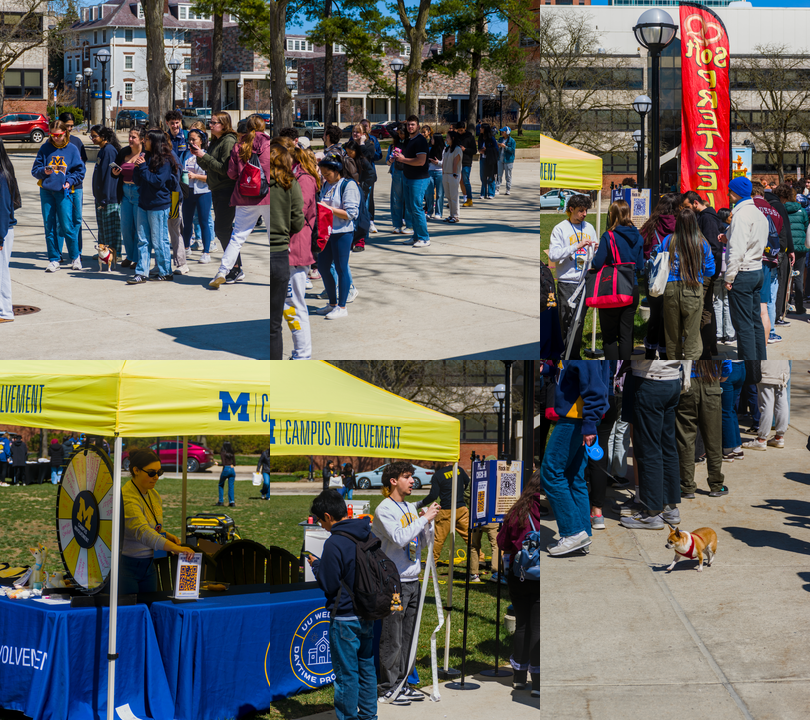

Example framed outputs (1080x1440)


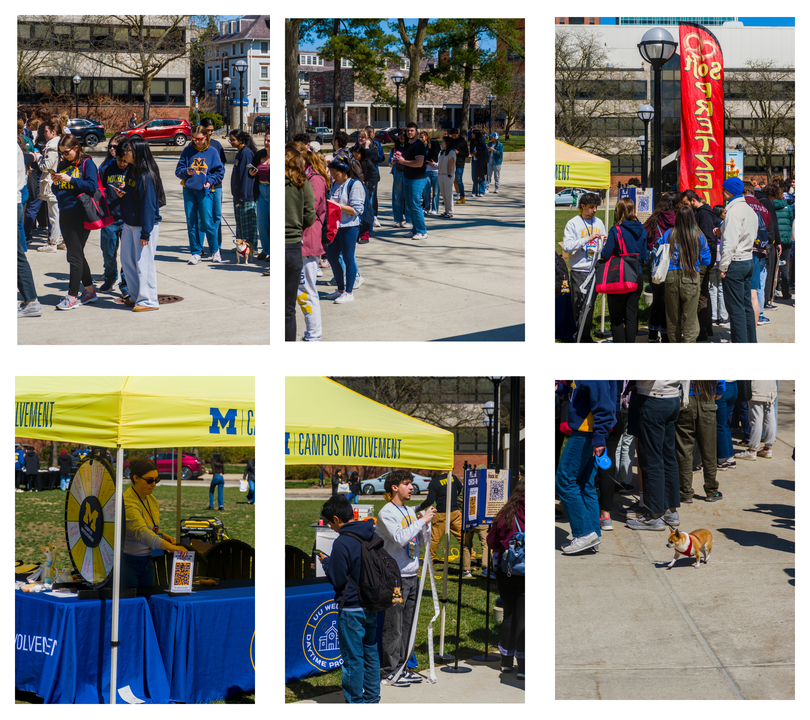

In [23]:
records, stats, framed_borders = process_all(CONFIG)

def validate_outputs(cfg: AppConfig, records: List[ProcessRecord], framed_borders: Dict[str, BorderSpec]) -> None:
    src_files = list_source_images(cfg)

    landscapes = []
    portraits = []
    for p in src_files:
        img = load_image(p)
        (landscapes if is_landscape(img) else portraits).append(p)

    processed_files = sorted([p.name for p in cfg.processed_dir.glob("*.jpg")])
    framed_files = sorted([p.name for p in cfg.framed_dir.glob("*.jpg")])

    expected = len(portraits) + 2 * len(landscapes)
    assert len(processed_files) == expected, (
        f"Processed count mismatch: expected {expected}, got {len(processed_files)}"
    )
    assert len(framed_files) == expected, (
        f"Framed count mismatch: expected {expected}, got {len(framed_files)}"
    )

    for p in landscapes:
        assert p.name not in processed_files, (
            f"Landscape original found in processed output: {p.name}"
        )
        assert f"{p.stem}_L.jpg" in processed_files
        assert f"{p.stem}_R.jpg" in processed_files
        assert f"{p.stem}_L.jpg" in framed_files
        assert f"{p.stem}_R.jpg" in framed_files

    for framed_name in framed_files:
        with Image.open(cfg.framed_dir / framed_name) as img:
            assert img.size == cfg.target_size, (
                f"Framed output is not {cfg.target_size}: {framed_name}, got {img.size}"
            )

    # Border validation for split outputs and baseline frame validation.
    for name, b in framed_borders.items():
        if name.endswith("_L.jpg"):
            assert b.right == 0, f"Left split must have zero right border: {name}"
            assert b.left >= cfg.baseline_frame_width, (
                f"Left split outer border below baseline: {name}, left={b.left}"
            )
            assert b.top >= cfg.baseline_frame_width
            assert b.bottom >= cfg.baseline_frame_width
        elif name.endswith("_R.jpg"):
            assert b.left == 0, f"Right split must have zero left border: {name}"
            assert b.right >= cfg.baseline_frame_width, (
                f"Right split outer border below baseline: {name}, right={b.right}"
            )
            assert b.top >= cfg.baseline_frame_width
            assert b.bottom >= cfg.baseline_frame_width
        else:
            assert b.left >= cfg.baseline_frame_width
            assert b.right >= cfg.baseline_frame_width
            assert b.top >= cfg.baseline_frame_width
            assert b.bottom >= cfg.baseline_frame_width

    print("Validation checks passed.")


def print_size_diagnostics(cfg: AppConfig, records: List[ProcessRecord], sample_count: int = 8) -> None:
    print("\nFile size diagnostics (KB)")
    print("source -> processed -> framed")

    for rec in records[:sample_count]:
        src = cfg.source_dir / rec.source_name
        proc = cfg.processed_dir / rec.processed_outputs[0]
        frm = cfg.framed_dir / rec.framed_outputs[0]

        src_kb = bytes_to_kb(src)
        proc_kb = bytes_to_kb(proc)
        frm_kb = bytes_to_kb(frm)
        print(f"{rec.source_name}: {src_kb:.1f} -> {proc_kb:.1f} -> {frm_kb:.1f}")


validate_outputs(CONFIG, records, framed_borders)
print("Final run summary:")
print(f"Portrait/square inputs: {stats.portraits}")
print(f"Landscape inputs: {stats.landscapes}")
print(f"Processed files written: {stats.processed_written}")
print(f"Framed files written: {stats.framed_written}")
print(f"Errors: {stats.errors}")
print_size_diagnostics(CONFIG, records)
show_example_outputs(CONFIG, records, max_examples=6)